# 02 - Collecting Expert Demonstrations

Behavioural Cloning needs a dataset `D = {(obs, expert_action)}`. We roll the champion out in the 1v1 env and record, for **every** car at **every** step, the observation and the expert's **deterministic (argmax)** action - the target we want the student to reproduce.

**We collect from real games (kickoff starts).** Every episode begins at a normal kickoff and plays out; the orange car *executes* stochastic samples (while still being recorded with its argmax label) so games diverge and we get varied, realistic trajectories. This **narrow, on-task distribution** is deliberate: it is exactly where Behavioural Cloning's *covariate shift* bites (the student drifts off the expert's trajectories at deployment) and therefore where DAgger earns its keep in notebook 04. (Collecting from wildly randomized states instead would broaden the demo distribution and *mask* the covariate-shift problem.) This is the dataset notebook 03 trains on.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # make imitation/ importable -> il_core (cwd = notebooks/)
import il_core
il_core.use_repo_cwd()                       # chdir to repo root so RocketSim finds ./collision_meshes/
import numpy as np
import matplotlib.pyplot as plt
from il_core import (ExpertPolicy, BCStudent, DemoBuffer, collect_expert_demos,
                     train_bc, rollout_student_relabel, evaluate_student_winrate,
                     save_student_checkpoint, build_env, OBS_DIM, N_ACTIONS,
                     EXPERT_CKPT, DATA_DIR, ARTIFACT_DIR, REPO_ROOT)
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(ARTIFACT_DIR, exist_ok=True)
print('engine loaded | OBS_DIM', OBS_DIM, '| N_ACTIONS', N_ACTIONS)

engine loaded | OBS_DIM 107 | N_ACTIONS 90


## Config
`N_EPISODES` is deliberately modest so this runs quickly and barely disturbs the live PPO training sharing the CPU. Scale it up (e.g. 200+) for the final submission numbers when the CPU is free.

In [2]:
N_EPISODES = 30      # bump to 200+ for final numbers
MAX_SECONDS = 20     # per-episode cap (game seconds)
SEED = 0

In [3]:
expert = ExpertPolicy(device='cpu')
def _p(ep, tot, n): print(f'  episode {ep}/{tot}  |  {n} pairs so far', flush=True)
buf = collect_expert_demos(expert, N_EPISODES, max_seconds=MAX_SECONDS,
                           randomize=False, seed=SEED, progress=_p)  # kickoff games
buf.save(DATA_DIR)
print('\nsaved', len(buf), 'demonstrations to', DATA_DIR)

  episode 1/30  |  600 pairs so far


  episode 2/30  |  1200 pairs so far


  episode 3/30  |  1800 pairs so far


  episode 4/30  |  2400 pairs so far


  episode 5/30  |  2542 pairs so far


...

  episode 27/30  |  12580 pairs so far


  episode 28/30  |  13180 pairs so far


  episode 29/30  |  13536 pairs so far


  episode 30/30  |  14136 pairs so far



saved 14136 demonstrations to C:\Users\Lasca\Desktop\Pro\IE\Courses\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\Group Project\rlgym\imitation\data


## Dataset analysis
Size, action usage, episode returns/lengths, and observation stats.

In [4]:
X, y = buf.observations, buf.actions
print('observations:', X.shape, '| actions:', y.shape)
print('distinct actions used:', len(np.unique(y)), '/', N_ACTIONS)
print('episodes:', len(buf.episode_lengths),
      '| mean length:', round(float(np.mean(buf.episode_lengths)), 1),
      '| mean result:', round(float(np.mean(buf.episode_returns)), 3))

observations: (14136, 107) | actions: (14136,)
distinct actions used: 90 / 90
episodes: 30 | mean length: 235.6 | mean result: 0.6


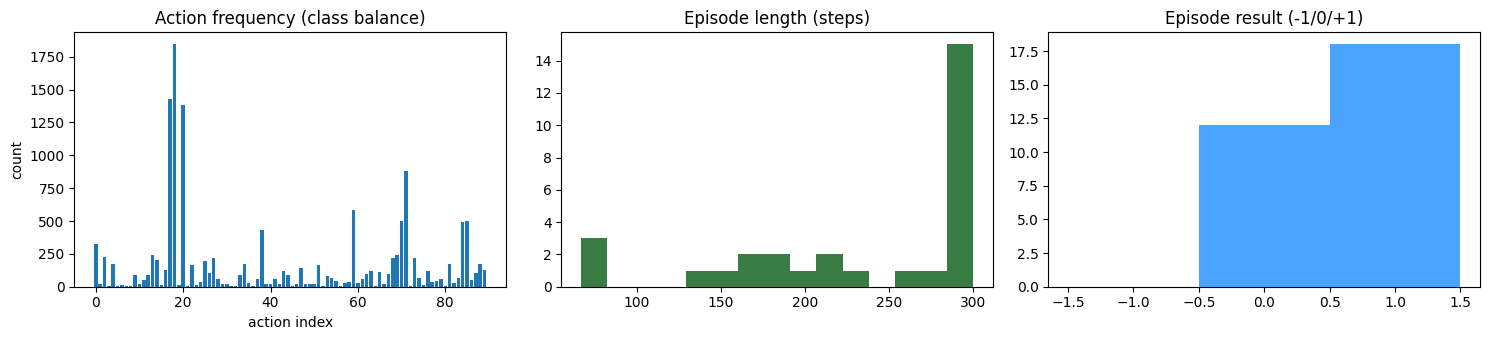

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
counts = np.bincount(y, minlength=N_ACTIONS)
ax[0].bar(range(N_ACTIONS), counts); ax[0].set_title('Action frequency (class balance)')
ax[0].set_xlabel('action index'); ax[0].set_ylabel('count')
ax[1].hist(buf.episode_lengths, bins=15, color='#3a7d44'); ax[1].set_title('Episode length (steps)')
ax[2].hist(buf.episode_returns, bins=[-1.5,-0.5,0.5,1.5], color='#4aa3ff'); ax[2].set_title('Episode result (-1/0/+1)')
plt.tight_layout(); plt.show()

In [6]:
# class imbalance summary -> motivates why top-1 accuracy alone can mislead
frac = counts / counts.sum()
order = np.argsort(frac)[::-1]
print('most common action %4d used %.1f%% of the time' % (order[0], 100*frac[order[0]]))
print('top-5 actions cover %.1f%% of all demonstrations' % (100*frac[order[:5]].sum()))
print('a majority-class baseline would score top-1 acc =', round(float(frac.max()), 3))

most common action   18 used 13.0% of the time
top-5 actions cover 43.3% of all demonstrations
a majority-class baseline would score top-1 acc = 0.13


**Research note (covered in 03).** The action distribution is highly imbalanced - a handful of controls dominate. That sets the bar: a trivial 'always predict the most common action' baseline already gets the accuracy printed above, so the BC student must beat *that* to show it learned the expert's state-dependent behaviour, not just the marginal.